In [1]:
# 05.09.2026 - 20260905c.ipynb: GLEBOKOSC MINIMOW SEKCJI 4 DLA MOSKWY -
# SKAD BIERZE SIE NIEDOBOR I CO GO ZAMYKA.
#
# JEDEN watek (konwencja repo). 20260905a zamknal sprawe DAT: krata t0 sekcji 4
# to krok 5 dni o fazie 07:37:12 GMT, potwierdzona dwoma niezaleznymi sposobami
# (polozenie pieciu dat na jednej kracie + odtworzenie faktorow kary
# 2682/1952/1207). Zostala GLEBOKOSC: w opublikowanych datach nasza statystyka
# jest plytsza o 0,24-3,25 dekady (min5 najgorzej). Ten notebook pyta o jedna
# rzecz: ILE Z TEGO NIEDOBORU BIERZE SIE Z KONWENCJI BINOWANIA, A ILE Z WERSJI
# PLIKU CR - i mierzy to na liczbach OPUBLIKOWANYCH, nie na naszych wlasnych.
#
# CO JEST NOWEGO WZGLEDEM 19.08 (20260819c.ipynb, gdzie po raz pierwszy
# porownywalismy sie z kodem zespolu). Wtedy porownanie konczylo sie na jednym
# punkcie sekcji 3 i na wniosku "jedyny konsekwentnie dzialajacy czynnik to
# wybor danych CR". Od tamtej pory (a) wiemy, na jakiej kracie stoi sekcja 4,
# wiec da sie zapytac o glebokosc w opublikowanych PUNKTACH, (b) przeczytanie
# pdf_values8.py raz jeszcze pokazalo dwie rzeczy, ktorych 19.08 nie nazwal:
#
#   (1) KOTWICA KRATY NIE JEST t0. Kod zespolu grupuje przez
#       pd.Grouper(freq="5D", origin="start"), a "start" to PIERWSZY REKORD
#       PRZEFILTROWANYCH DANYCH, nie podane t0. Dla CR (probki co 6 h) daje to
#       krate o fazie 00/06/12/18, a nie 07:37:12; dla EQ - krate zakotwiczona
#       na CZASIE PIERWSZEGO TRZESIENIA w oknie. Widac to wprost w zapisanym
#       przez zespol pliku pdf_Mosc_2013-11-14 07-00-00.csv: t0 = 07:00:00, a
#       etykiety koszy to "cr date" 12:00:00 i "eq date" 07:04:21.
#       KONSEKWENCJA: efektywne przesuniecie EQ wzgledem CR NIE wynosi 15,000
#       dnia, tylko 15 d + (jitter EQ) - (jitter CR); dla punktu sekcji 3
#       Moskwy jest to 14 d 19:04:21, czyli o 4 h 56 min mniej niz nominalne
#       dt. Przy zmierzonej 05.09 wrazliwosci (~0,9 sigma na godzine dla
#       Moskwy) to nie jest drobiazg.
#
#   (2) OKNO ZACZYNA SIE O JEDEN KOSZ WCZESNIEJ. Kod filtruje CR od t0 - 5 dni
#       (i EQ od t0 + dt - 5 dni), wiec pierwsza roznica dCR liczy sie juz dla
#       kosza zaczynajacego sie w t0. Nasz cosmoseismic_stat zaczyna od t0 i
#       traci ten kosz: przy P = 1675 mamy 334 pary, zespol 335; przy P = 3350
#       mamy 669, zespol 670.
#
# Do tego dochodza trzy drobniejsze roznice konwencji (mediany liczone po
# filtrze zamiast przed, skrocony filtr zamiast pelnego rownania (3), remisy
# C = 0 wliczane do N zamiast odrzucane) - wszystkie sa tu przelacznikami.
#
# I DRUGA POLOWA PYTANIA - DANE. Porownanie naszego data/mosc_data.csv z plikiem
# z archiwum CREDO (zrodla/kod/dane/mosc_data2.csv, wersja z 20.10.2023) daje
# obraz, ktorego 19.08 nie mial w tej postaci:
#   - do 2009-12-31 12:00 oba pliki sa IDENTYCZNE na wspolnych znacznikach,
#     od 2010-01-01 00:00 rozne (14 151 z 83 857 wspolnych rekordow),
#   - archiwum ma 1571 znacznikow, ktorych my NIE MAMY, skupionych w latach
#     1960-62, 1966 i 1968; w szczegolnosci NASZ plik ma 62-dniowa dziure
#     1968-06-30 -> 1968-09-01, a archiwum w tym samym miejscu 8-dniowa.
#     Pierwsze minimum artykulu ma t0 = 1968-07-12, czyli LEZY W SRODKU
#     NASZEJ DZIURY.
# Komorka 3 liczy to formalnie, okno po oknie. Wniosek roboczy do sprawdzenia:
# ery 1-4 stoja na CR, ktore mamy bit w bit takie samo jak zespol (poza
# dziurami), a era 5 stoi w calosci na CR, ktore sie rozjezdza - i akurat era 5
# ma najwiekszy niedobor glebokosci.
#
# CZEGO TEN NOTEBOOK NIE ROBI. Nie dotyka Oulu (20260905b), nie zmienia niczego
# w prezentacji, nie przelicza watku surogatowego. Nie pobiera tez nic z NMDB -
# pytanie, ktora wersja produktu NMDB odpowiada plikowi z archiwum po 2010
# (nasz skrypt bierze tabchoice=revori&dtype=corr_for_efficiency), zostaje
# otwarte i jest do zalatwienia osobnym pobraniem, nie tutaj.
#
# WEJSCIA:
#   ../data/mosc_data.csv                              (NMDB, nasze pobranie)
#   ../zrodla/kod/dane/mosc_data2.csv                  (archiwum CREDO, 20.10.2023)
#   ../data/usgs_data/usgs_m4_1965_2025.csv            (USGS, M >= 4,0, 1965-2025)
#   ../zrodla/kod/dane/eq_data.csv                     (katalog EQ zespolu)
#   ../zrodla/kod/dane/pdf_Mosc_2013-11-14 07-00-00.csv (tabela koszy zespolu)
#   ../data/SN_m_tot_V2.0.csv                          (SILSO)
# WYJSCIA: ../results/replikacja_glebokosc_*.csv i *_{pl,en}.png
import sys
import time
from functools import partial

import numpy as np
import pandas as pd
from scipy.stats import binom, norm, chi2
from scipy.signal import find_peaks

sys.path.insert(0, "..")
from mc_parallel import run_t0_scan_parallel

RESULTS_DIR = "../results"
ARCH_DIR = "../źródła/kod/dane/"          # zrodla/kod/dane/ (nazwa katalogu z polskimi znakami)
MOSC_NASZ_PATH = "../data/mosc_data.csv"
MOSC_ARCH_PATH = ARCH_DIR + "mosc_data2.csv"
USGS_PATH = "../data/usgs_data/usgs_m4_1965_2025.csv"
EQ_ARCH_PATH = ARCH_DIR + "eq_data.csv"
TABELA_ZESPOLU = ARCH_DIR + "pdf_Mosc_2013-11-14 07-00-00.csv"
SUNSPOT_PATH = "../data/SN_m_tot_V2.0.csv"

P_DAYS = 3350        # sekcja 4
P3_DAYS = 1675       # sekcja 3
D_DAYS = 5
M_THRESHOLD = 4.0
DT_DAYS = 15
KROK_ART = pd.Timedelta(days=D_DAYS)
BURNING_START = pd.Timestamp("2005-03-30")

# Piec minimow sekcji 4 (PPDF z wzoru iloczynu, str. 5 artykulu) - tabela
# przepisana z 20260905a.ipynb, zeby ten notebook byl samodzielny.
ARTYKUL = pd.DataFrame([
    dict(nr=1, t0=pd.Timestamp("1969-07-12 07:37:12"), PPDF=3.34e-8, faktor=3430, w_iloczynie=True),
    dict(nr=2, t0=pd.Timestamp("1978-07-11 07:37:12"), PPDF=3.00e-6, faktor=2682, w_iloczynie=True),
    dict(nr=3, t0=pd.Timestamp("1988-09-21 07:37:12"), PPDF=3.58e-5, faktor=1952, w_iloczynie=True),
    dict(nr=4, t0=pd.Timestamp("1999-12-23 07:37:12"), PPDF=2.92e-6, faktor=1207, w_iloczynie=True),
    dict(nr=5, t0=pd.Timestamp("2009-02-23 07:37:12"), PPDF=8.10e-9, faktor=np.nan, w_iloczynie=False),
])
ARTYKUL["neglog10_PPDF"] = -np.log10(ARTYKUL["PPDF"])
KOTWICA = ARTYKUL.loc[ARTYKUL["nr"] == 5, "t0"].iloc[0]
# Drukowany rok pierwszego minimum to literowka (ustalone 31.08); krata daje 1968-07-13.
MIN1_1968 = pd.Timestamp("1968-07-12 07:37:12")
MIN1_NA_KRACIE = KOTWICA + round((MIN1_1968 - KOTWICA) / KROK_ART) * KROK_ART

# Punkt odniesienia sekcji 3 dla Moskwy - JEDYNE miejsce w artykule z liczbami
# CALKOWITYMI dla Moskwy (N+ = 218, N- = 113, PCDF = 4,1e-9, ~5,76 sigma).
T0_SEKCJA3 = pd.Timestamp("2013-11-14 07:00:00")
SEKCJA3_NP, SEKCJA3_NM = 218, 113


def load_cr(path):
    df = pd.read_csv(path)
    df["datetime"] = pd.to_datetime(df["datetime"])
    s = df.set_index("datetime").sort_index()["value"]
    return s[~s.index.duplicated(keep="first")]


def load_eq(path, kol_czasu="time", utc=False, min_mag=M_THRESHOLD):
    df = pd.read_csv(path, usecols=[kol_czasu, "mag"])
    if utc:
        df[kol_czasu] = pd.to_datetime(df[kol_czasu], utc=True).dt.tz_localize(None)
    else:
        df[kol_czasu] = pd.to_datetime(df[kol_czasu])
    df = df[df["mag"] >= min_mag]
    return df.set_index(kol_czasu)["mag"].sort_index()


mosc_nasz = load_cr(MOSC_NASZ_PATH)
mosc_arch = load_cr(MOSC_ARCH_PATH)
# Wariant "uzupelniony": NASZE wartosci wszedzie, gdzie je mamy, plus rekordy z
# archiwum w znacznikach, ktorych nam brakuje. Izoluje efekt DZIUR od efektu
# ROZJECHANIA SIE WARTOSCI po 2010 - bo tam, gdzie oba pliki maja rekord,
# ten wariant bierze nasz.
_brakujace = mosc_arch.index.difference(mosc_nasz.index)
mosc_uzup = pd.concat([mosc_nasz, mosc_arch.loc[_brakujace]]).sort_index()

eq_nasz = load_eq(USGS_PATH, utc=True)
eq_arch = load_eq(EQ_ARCH_PATH)

CR = {"nasz": mosc_nasz, "archiwum": mosc_arch, "uzupelniony": mosc_uzup}
EQ = {"USGS": eq_nasz, "archiwum": eq_arch}

for _n, _s in CR.items():
    print(f"CR Moskwa [{_n:<12}]: {len(_s):>7} probek, {_s.index.min()} .. {_s.index.max()}")
for _n, _s in EQ.items():
    print(f"EQ         [{_n:<12}]: {len(_s):>7} zdarzen M >= {M_THRESHOLD}, "
          f"{_s.index.min()} .. {_s.index.max()}")
print(f"\nRekordow dolozonych do wariantu 'uzupelniony': {len(_brakujace)}")


# ---------------------------------------------------------------------------
# IMPLEMENTACJA REFERENCYJNA - przepisana ZNAK W ZNAK z 20260824f/20260905a.
# To ona policzyla wszystkie pliki finetune_*.csv i zweryfikowany punkt z 24.08;
# wystepuje tu jako punkt odniesienia ("nasza konwencja"), zeby bylo widac, ze
# nowa, parametryzowana funkcja odtwarza ja co do bitu.
# ---------------------------------------------------------------------------
def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)

    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


# ---------------------------------------------------------------------------
# IMPLEMENTACJA PARAMETRYZOWANA. Pieciu przelacznikami przechodzi plynnie od
# NASZEJ konwencji do konwencji z kodu zespolu (pdf_values8.py). Zadna wartosc
# domyslna nie jest "ta wlasciwa" - kazdy wynik w tym notebooku ma przy sobie
# jawnie wypisany zestaw przelacznikow.
#
#   kotwica       "nominalna" - krawedzie dokladnie w t0 + k*d (nasze)
#                 "dane"      - krata zaczyna sie w PIERWSZYM DOSTEPNYM rekordzie
#                               (CR: pierwsza probka, EQ: pierwsze trzesienie);
#                               to jest odtworzenie origin="start" z kodu zespolu
#   wiodacy_kosz  czy okno zaczyna sie o jeden kosz przed t0 (zespol: tak)
#   mediany       "wszystkie" (nasze) / "po_filtrze" (zespol)
#   filtr         "pelny"    - rownanie (3) artykulu: nCR(i)>0, nCR(i-1)>0, Sm>0
#                 "skrocony" - to, co jest w kodzie zespolu: nCR(i)>0, |dCR|>0
#   remisy        "odrzucone" (nasze: C = 0 wypada z N) / "w_N" (zespol: zostaje
#                 w mianowniku, ale nie liczy sie do Np)
#
# UWAGA O WIERNOSCI. Kod zespolu wyznacza liczbe koszy z rozpietosci danych
# (n = floor(span/d) + 1); tutaj jest ona ustalona na P/d (+1 przy wiodacym
# koszu). Przy gestych danych to jest to samo - i komorka 2 sprawdza to na
# zapisanej przez zespol tabeli 332 wierszy, kolumna po kolumnie. Przy danych
# z duza dziura na poczatku okna oba podejscia moga sie rozejsc, dlatego funkcja
# zwraca zrealizowana kotwice i efektywne dt - komorka 5 je wypisuje.
# ---------------------------------------------------------------------------
def credo_kosze(cr, eq, t0, P_days, d_days, dt_days, kotwica="dane",
                wiodacy_kosz=True, mediany="po_filtrze", filtr="skrocony",
                remisy="w_N"):
    t0 = pd.Timestamp(t0)
    n_koszy = int(P_days // d_days) + (1 if wiodacy_kosz else 0)
    start_cr_nom = t0 - pd.Timedelta(days=d_days) if wiodacy_kosz else t0
    start_eq_nom = start_cr_nom + pd.Timedelta(days=dt_days)
    # granice gorne dokladnie jak w pdf_values8.py (d_end liczone osobno dla CR i EQ)
    kon_cr = t0 + pd.Timedelta(days=P_days)
    kon_eq = t0 + pd.Timedelta(days=dt_days + P_days)

    cr = cr[(cr.index >= start_cr_nom) & (cr.index <= kon_cr)]
    eq = eq[(eq.index >= start_eq_nom) & (eq.index <= kon_eq)]
    if len(cr) == 0 or len(eq) == 0:
        return None

    if kotwica == "dane":
        start_cr, start_eq = cr.index[0], eq.index[0]
    else:
        start_cr, start_eq = start_cr_nom, start_eq_nom

    kr_cr = pd.date_range(start_cr, periods=n_koszy + 1, freq=pd.Timedelta(days=d_days))
    kr_eq = pd.date_range(start_eq, periods=n_koszy + 1, freq=pd.Timedelta(days=d_days))

    cr_cats = pd.cut(cr.index, kr_cr, right=False)
    cr_vals = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories).to_numpy()
    eq_cats = pd.cut(eq.index, kr_eq, right=False)
    sm_vals = (eq.groupby(eq_cats, observed=False).sum()
               .reindex(eq_cats.categories, fill_value=0.0).to_numpy())

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = np.abs(nCR_i - nCR_im1)
    Sm = sm_vals[1:]

    with np.errstate(invalid="ignore", divide="ignore"):
        if filtr == "skrocony":
            dane_ok = (nCR_i > 0) & (dCR > 0)
        else:
            dane_ok = (nCR_i > 0) & (nCR_im1 > 0) & (Sm > 0) & ~np.isnan(dCR)

        baza = dane_ok if mediany == "po_filtrze" else np.ones(len(Sm), dtype=bool)
        if not baza.any():
            return None
        med_Sm = np.nanmedian(Sm[baza])
        med_dCR = np.nanmedian(dCR[baza])
        A = Sm / med_Sm - 1.0
        B = dCR / med_dCR - 1.0
        C = np.sign(A * B)

        wazne = dane_ok & ~np.isnan(A) & ~np.isnan(B)
        if remisy == "odrzucone":
            wazne = wazne & (A != 0) & (B != 0)

    N = int(wazne.sum())
    Np = int((C[wazne] > 0).sum())
    Nm = int((C[wazne] < 0).sum())
    if N == 0:
        return None
    ppdf = binom.pmf(Np, N, 0.5)
    pcdf = binom.sf(Np - 1, N, 0.5)
    return dict(
        N=n_koszy, N_valid=N, Np=Np, Nm=Nm, remisow=N - Np - Nm,
        PPDF=float(ppdf), PCDF=float(pcdf), sigma=float(norm.isf(pcdf)),
        med_Sm=float(med_Sm), med_dCR=float(med_dCR),
        start_cr=start_cr, start_eq=start_eq,
        dt_efektywne_d=(start_eq - start_cr) / pd.Timedelta(days=1),
        jitter_cr_h=(start_cr - start_cr_nom) / pd.Timedelta(hours=1),
        jitter_eq_h=(start_eq - start_eq_nom) / pd.Timedelta(hours=1),
        kraw_cr=kr_cr[1:-1], kraw_eq=kr_eq[1:-1],
        cr_mean=nCR_i, Sm=Sm, dCR=dCR, A=A, B=B, C=C, wazne=wazne,
    )


_KOLUMNY_SKALARNE = ("N", "N_valid", "Np", "Nm", "remisow", "PPDF", "PCDF", "sigma",
                     "med_Sm", "med_dCR", "dt_efektywne_d", "jitter_cr_h", "jitter_eq_h")


def credo_stat(cr, eq, t0, P_days, d_days, m, dt_days, **przelaczniki):
    r = credo_kosze(cr, eq, t0, P_days, d_days, dt_days, **przelaczniki)
    if r is None:
        return dict(N=0, N_valid=0, Np=0, Nm=0, remisow=0, PPDF=np.nan,
                    PCDF=np.nan, sigma=np.nan, med_Sm=np.nan, med_dCR=np.nan,
                    dt_efektywne_d=np.nan, jitter_cr_h=np.nan, jitter_eq_h=np.nan)
    return {k: r[k] for k in _KOLUMNY_SKALARNE}


# Dwa gotowe zestawy przelacznikow.
NASZE = dict(kotwica="nominalna", wiodacy_kosz=False, mediany="wszystkie",
             filtr="pelny", remisy="odrzucone")
CREDO = dict(kotwica="dane", wiodacy_kosz=True, mediany="po_filtrze",
             filtr="skrocony", remisy="w_N")
OPIS_PRZELACZNIKA = {
    "wiodacy_kosz": "okno o kosz wczesniej",
    "kotwica": "kotwica kraty",
    "mediany": "kiedy mediany",
    "filtr": "filtr rownania (3)",
    "remisy": "remisy C = 0",
}


def policz(stat_fn, cr, eq, t0_lista, P_days=P_DAYS, save_path=None, prog_rownolegly=64):
    t0_lista = pd.DatetimeIndex(t0_lista).sort_values()
    if len(t0_lista) <= prog_rownolegly:
        df = pd.DataFrame([
            {**stat_fn(cr, eq, t0, P_days, D_DAYS, M_THRESHOLD, DT_DAYS), "t0": t0}
            for t0 in t0_lista
        ])
    else:
        od = t0_lista.min() - pd.Timedelta(days=D_DAYS + 1)
        do = t0_lista.max() + pd.Timedelta(days=P_days + DT_DAYS + D_DAYS + 1)
        crc = cr[(cr.index >= od) & (cr.index <= do)]
        eqc = eq[(eq.index >= od) & (eq.index <= do)]
        df = run_t0_scan_parallel(crc, eqc, t0_lista, P_days=P_days, d_days=D_DAYS,
                                  m=M_THRESHOLD, dt_days=DT_DAYS, stat_fn=stat_fn)
    df = df.sort_values("t0").reset_index(drop=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        df["neglog10_PPDF"] = -np.log10(df["PPDF"])
    if save_path is not None:
        df.to_csv(save_path, index=False)
    return df


print("\nGotowe: dwie implementacje statystyki + trzy warianty CR + dwa katalogi EQ.")

CR Moskwa [nasz        ]:   91824 probek, 1960-01-01 00:00:00 .. 2025-03-23 18:00:00
CR Moskwa [archiwum    ]:   85428 probek, 1960-01-01 06:00:00 .. 2019-12-11 06:00:00
CR Moskwa [uzupelniony ]:   93395 probek, 1960-01-01 00:00:00 .. 2025-03-23 18:00:00
EQ         [USGS        ]:  507919 zdarzen M >= 4.0, 1965-01-01 08:04:17.780000 .. 2025-01-31 23:57:39.481000
EQ         [archiwum    ]:  359436 zdarzen M >= 4.0, 1960-01-02 12:21:58 .. 2019-12-31 23:56:59

Rekordow dolozonych do wariantu 'uzupelniony': 1571

Gotowe: dwie implementacje statystyki + trzy warianty CR + dwa katalogi EQ.


In [ ]:
# KOMORKA 1 - CEL LICZBOWY. Porownywanie sie z artykulem w dekadach -log10(PPDF)
# jest niewygodne, bo dekady zaleza jednoczesnie od liczby koszy i od nadwyzki
# znakow. Statystyka artykulu jest jednak DYSKRETNA: PPDF = C(N, Np) * 0,5^N,
# wiec z opublikowanej wartosci da sie odzyskac pare liczb calkowitych.
#
# Trzy cyfry znaczace nie wystarczaja, zeby wyznaczyc N jednoznacznie - ale
# WSZYSTKIE pasujace pary maja niemal te sama NADWYZKE |Np - N/2|. To jest
# wielkosc, ktora naprawde chcemy odtworzyc, i jest odporna na nieznane N.
#
# UWAGA O ZNAKU, KLUCZOWA DLA CALEGO POROWNANIA. PPDF = C(N, Np) * 0,5^N jest
# SYMETRYCZNE wzgledem zamiany Np <-> Nm: N = 670, Np = 401 i N = 670, Np = 269
# daja identyczna wartosc. Sekcja 4 artykulu podaje wylacznie PPDF, wiec
# Z OPUBLIKOWANYCH LICZB NIE DA SIE ODCZYTAC, KTORA STRONA WYGRYWALA w danej
# erze. Celem jest zatem WARTOSC BEZWZGLEDNA nadwyzki, a znak jest osobna,
# niezalezna obserwacja (komorka 5, kolumna 'znak'). Porownywanie nadwyzki ze
# znakiem byloby bledem: era wychodzaca disordering z |nadwyzka| = 69 wobec celu
# 67,5 jest trafiona co do 1,5 kosza, a nie chybiona o 136.
# (Inaczej jest w sekcji 3, gdzie artykul podaje N+ i N- osobno - tam znak jest
# czescia celu i komorka 4 porownuje sie z nim wprost.)
CEL = {}
print("JAKIE PARY (N, Np) DAJA OPUBLIKOWANE PPDF SEKCJI 4 (zakres N: 600-700)")
print("=" * 78)
for _, r in ARTYKUL.iterrows():
    p = float(r["PPDF"])
    pary = []
    for N in range(600, 701):
        for n in range(N // 2, N + 1):
            v = binom.pmf(n, N, 0.5)
            if v > p * 1.005:
                continue
            if v < p * 0.995:
                break
            pary.append((N, n))
    nadwyzki = [n - N / 2 for N, n in pary]
    # do porownan bierzemy pare o N najblizszym 669/670 (tyle koszy ma okno
    # P = 3350 przy d = 5); nadwyzka i tak prawie nie zalezy od wyboru
    N_ref, Np_ref = min(pary, key=lambda t: abs(t[0] - 670))
    CEL[int(r["nr"])] = dict(N=N_ref, Np=Np_ref, nadwyzka=Np_ref - N_ref / 2,
                             nadwyzka_min=min(nadwyzki), nadwyzka_max=max(nadwyzki))
    print(f"min{int(r['nr'])}  {r['t0'].date()}  PPDF = {p:.2e}  -log10 = {r['neglog10_PPDF']:.2f}")
    print(f"      pasujacych par: {len(pary):>2}   nadwyzka Np - N/2 w przedziale "
          f"[{min(nadwyzki):+.1f}, {max(nadwyzki):+.1f}]")
    print(f"      para o N najblizszym 670:  N = {N_ref}, Np = {Np_ref}, "
          f"Nm = {N_ref - Np_ref}, nadwyzka = {Np_ref - N_ref / 2:+.1f}")

print("\nWNIOSEK. Opublikowane PPDF jednoznacznie wyznaczaja NADWYZKE ZNAKOW z")
print("dokladnoscia do ~1 kosza, mimo ze samego N nie wyznaczaja. Wszystkie")
print("wartosci N w rozwiazaniach mieszcza sie w okolicy 670, czyli tyle, ile ma")
print("okno P = 3350 przy d = 5 - to niezalezne potwierdzenie, ze artykul liczyl")
print("na tym samym oknie co my i ze u niego prawie zaden kosz nie wypadal.")
print("\nDalej porownujemy sie WLASNIE nadwyzka Np - N/2, a dekady podajemy obok.")

# Kontrola samozgodnosci opublikowanych liczb calkowitych sekcji 3.
_pcdf3 = binom.sf(SEKCJA3_NP - 1, SEKCJA3_NP + SEKCJA3_NM, 0.5)
print(f"\nKontrola sekcji 3: N+ = {SEKCJA3_NP}, N- = {SEKCJA3_NM} -> PCDF = {_pcdf3:.4e}, "
      f"sigma = {norm.isf(_pcdf3):.3f}")
print("  artykul podaje PCDF = 4,1e-9 - opublikowane liczby calkowite sa samozgodne,")
print("  wiec moga sluzyc za twardy cel (nadwyzka = "
      f"{SEKCJA3_NP - (SEKCJA3_NP + SEKCJA3_NM) / 2:+.1f} znaku).")

In [3]:
# KOMORKA 2 - WALIDACJA. Zanim cokolwiek wywnioskujemy z przelacznikow, trzeba
# pokazac, ze parametryzowana funkcja rzeczywiscie odtwarza (a) nasza wlasna
# konwencje co do bitu i (b) konwencje zespolu co do bitu.
#
# (a) jest latwe: credo_stat z zestawem NASZE ma dac to samo, co
#     cosmoseismic_stat, ta sama funkcja, ktora policzyla finetune_*.csv.
# (b) jest mocniejsze niz cokolwiek, co robilismy do tej pory: archiwum CREDO
#     zawiera ZAPISANA TABELE KOSZY dla punktu sekcji 3 Moskwy
#     (pdf_Mosc_2013-11-14 07-00-00.csv, 332 wiersze, kolumny cr mean / eq sum /
#     cr delta3 / eq median / cr median / A / B / C). Porownujemy sie z nia
#     WIERSZ PO WIERSZU, nie tylko koncowa liczba.
print("(a) credo_stat[NASZE] == cosmoseismic_stat ?")
_kontrola_a = []
for _t0 in [T0_SEKCJA3, MIN1_1968, ARTYKUL.loc[2, "t0"], ARTYKUL.loc[4, "t0"]]:
    for _P in (P3_DAYS, P_DAYS):
        _ref = cosmoseismic_stat(mosc_nasz, eq_nasz, _t0, _P, D_DAYS, M_THRESHOLD, DT_DAYS)
        _new = credo_stat(mosc_nasz, eq_nasz, _t0, _P, D_DAYS, M_THRESHOLD, DT_DAYS, **NASZE)
        _kontrola_a.append(dict(t0=_t0, P=_P, Np_ref=_ref["Np"], Np_new=_new["Np"],
                                Nm_ref=_ref["Nm"], Nm_new=_new["Nm"],
                                d_log10=abs(-np.log10(_ref["PPDF"]) + np.log10(_new["PPDF"]))))
_kontrola_a = pd.DataFrame(_kontrola_a)
print(_kontrola_a.to_string(index=False))
assert (_kontrola_a["Np_ref"] == _kontrola_a["Np_new"]).all(), \
    "credo_stat[NASZE] nie odtwarza cosmoseismic_stat - dalsze porownania nie maja sensu"
assert (_kontrola_a["Nm_ref"] == _kontrola_a["Nm_new"]).all()
assert _kontrola_a["d_log10"].max() < 1e-12
print("  OK - zgodnosc na 8 punktach (2 dlugosci okna x 4 daty), Np i Nm co do bitu.\n")

print("(b) credo_stat[CREDO] == zapisana tabela koszy zespolu ?")
zespol = pd.read_csv(TABELA_ZESPOLU)
zespol["cr date"] = pd.to_datetime(zespol["cr date"])
nasz = credo_kosze(mosc_arch, eq_arch, T0_SEKCJA3, P3_DAYS, D_DAYS, DT_DAYS, **CREDO)

_maska = nasz["wazne"]
tab = pd.DataFrame({
    "cr date": nasz["kraw_cr"][_maska],
    "cr mean": nasz["cr_mean"][_maska],
    "eq sum": nasz["Sm"][_maska],
    "cr delta3": nasz["dCR"][_maska],
    "A": nasz["A"][_maska],
    "B": nasz["B"][_maska],
    "C": nasz["C"][_maska],
})
print(f"  wierszy: my {len(tab)}, zespol {len(zespol)}")
print(f"  Np/Nm:   my {nasz['Np']}/{nasz['Nm']}, zespol "
      f"{int((zespol['C'] > 0).sum())}/{int((zespol['C'] < 0).sum())}")
print(f"  PPDF:    my {nasz['PPDF']:.15e}")
print(f"           zespol (z pliku pdf_data_Mosc.csv, d_end = 2018-06-16) 3.509338616358831e-08")
print(f"  mediany: my Sm = {nasz['med_Sm']:.10f}, |dCR| = {nasz['med_dCR']:.16f}")
print(f"           zespol Sm = {zespol['eq median'].iloc[0]:.10f}, "
      f"|dCR| = {zespol['cr median'].iloc[0]:.16f}")
print(f"  kotwice: CR {nasz['start_cr']} (jitter {nasz['jitter_cr_h']:+.3f} h), "
      f"EQ {nasz['start_eq']} (jitter {nasz['jitter_eq_h']:+.4f} h)")
print(f"  EFEKTYWNE dt = {nasz['dt_efektywne_d']:.6f} dnia zamiast nominalnych {DT_DAYS}")

_scal = tab.merge(zespol, on="cr date", suffixes=("_my", "_zesp"), how="outer", indicator=True)
print(f"\n  dopasowanie po dacie kosza: {int((_scal['_merge'] == 'both').sum())} wspolnych, "
      f"{int((_scal['_merge'] == 'left_only').sum())} tylko u nas, "
      f"{int((_scal['_merge'] == 'right_only').sum())} tylko u zespolu")
_ob = _scal[_scal["_merge"] == "both"]
for _kol in ["cr mean", "eq sum", "cr delta3", "A", "B", "C"]:
    _d = (_ob[f"{_kol}_my"] - _ob[f"{_kol}_zesp"]).abs().max()
    print(f"    max |roznica| w kolumnie {_kol:<10}: {_d:.3e}")

assert len(tab) == len(zespol), "inna liczba przezywajacych koszy niz w tabeli zespolu"
assert int((_scal["_merge"] == "both").sum()) == len(zespol), "kosze nie pokrywaja sie datami"
assert (_ob["C_my"] == _ob["C_zesp"]).all(), "znaki C nie zgadzaja sie kosz w kosz"
assert (nasz["Np"], nasz["Nm"]) == (214, 118), \
    f"konwencja zespolu na jego danych dala {nasz['Np']}/{nasz['Nm']}, oczekiwano 214/118"
# tolerancja 1e-9, bo binom.pmf idzie przez gammaln, a zespol liczyl
# math.comb(N, n) * 0.5**N - to sa dwie rozne drogi do tej samej liczby
assert abs(nasz["PPDF"] / 3.509338616358831e-08 - 1) < 1e-9, \
    "PPDF nie zgadza sie z wartoscia z pdf_data_Mosc.csv zespolu"
print("\n  OK - konwencja zespolu odtworzona KOSZ W KOSZ (332 wiersze, wszystkie kolumny)")
print("  i co do 15 cyfr w koncowym PPDF. To jest najmocniejsza kontrola pipeline'u,")
print("  jaka mamy w repo: porownanie z zapisanym wyjsciem cudzego kodu, nie z liczba")
print("  przepisana z artykulu.")

(a) credo_stat[NASZE] == cosmoseismic_stat ?
                 t0    P  Np_ref  Np_new  Nm_ref  Nm_new  d_log10
2013-11-14 07:00:00 1675     206     206     128     128      0.0
2013-11-14 07:00:00 3350     361     361     306     306      0.0
1968-07-12 07:37:12 1675     160     160     164     164      0.0
1968-07-12 07:37:12 3350     256     256     401     401      0.0
1988-09-21 07:37:12 1675     164     164     170     170      0.0
1988-09-21 07:37:12 3350     288     288     379     379      0.0
2009-02-23 07:37:12 1675     176     176     158     158      0.0
2009-02-23 07:37:12 3350     384     384     283     283      0.0
  OK - zgodnosc na 8 punktach (2 dlugosci okna x 4 daty), Np i Nm co do bitu.

(b) credo_stat[CREDO] == zapisana tabela koszy zespolu ?
  wierszy: my 332, zespol 332
  Np/Nm:   my 214/118, zespol 214/118
  PPDF:    my 3.509338616358796e-08
           zespol (z pliku pdf_data_Mosc.csv, d_end = 2018-06-16) 3.509338616358831e-08
  mediany: my Sm = 867.4200000000

In [4]:
# KOMORKA 3 - CO W OGOLE MOZE ZALEZEC OD WERSJI DANYCH. Zanim zaczniemy
# przelaczac konwencje, warto wiedziec, ktore z pieciu okien artykulu stoja na
# danych CR, ktore mamy takie same jak zespol, a ktore nie. Bez tego kazdy wynik
# da sie wytlumaczyc "no to pewnie dane" i nic z tego nie wynika.
#
# Dla kazdego okna liczymy osobno dla naszego pliku i dla archiwum: ile probek
# 6-godzinnych powinno byc, ile jest, jak dluga jest najdluzsza dziura, ile
# 5-dniowych koszy wypada calkiem pustych, oraz - na znacznikach wspolnych - jak
# bardzo wartosci sie roznia.
def pokrycie(seria, od, do, d_days=D_DAYS):
    w = seria[(seria.index >= od) & (seria.index <= do)]
    oczekiwane = int(round((do - od) / pd.Timedelta(hours=6)))
    if len(w) < 2:
        return dict(probek=len(w), oczekiwane=oczekiwane, luka_dni=np.nan, puste_kosze=np.nan)
    luka = w.index.to_series().diff().max()
    kraw = pd.date_range(od, do, freq=pd.Timedelta(days=d_days))
    zliczenia = pd.Series(pd.cut(w.index, kraw, right=False)).value_counts()
    return dict(probek=len(w), oczekiwane=oczekiwane,
                luka_dni=luka / pd.Timedelta(days=1),
                puste_kosze=int((zliczenia == 0).sum()))


OKNA = [dict(nazwa=f"min{int(r['nr'])}", t0=(MIN1_1968 if r["nr"] == 1 else r["t0"]), P=P_DAYS)
        for _, r in ARTYKUL.iterrows()]
OKNA.append(dict(nazwa="sekcja 3", t0=T0_SEKCJA3, P=P3_DAYS))

wiersze = []
for o in OKNA:
    cr_od = o["t0"] - pd.Timedelta(days=D_DAYS)
    cr_do = o["t0"] + pd.Timedelta(days=o["P"])
    eq_od = cr_od + pd.Timedelta(days=DT_DAYS)
    eq_do = cr_do + pd.Timedelta(days=DT_DAYS)
    pn = pokrycie(mosc_nasz, cr_od, cr_do)
    pa = pokrycie(mosc_arch, cr_od, cr_do)
    wn = mosc_nasz[(mosc_nasz.index >= cr_od) & (mosc_nasz.index <= cr_do)]
    wa = mosc_arch[(mosc_arch.index >= cr_od) & (mosc_arch.index <= cr_do)]
    wsp = wn.index.intersection(wa.index)
    rozne = int((np.abs(wn.loc[wsp] - wa.loc[wsp]) > 1e-9).sum()) if len(wsp) else 0
    wiersze.append(dict(
        okno=o["nazwa"], t0=o["t0"], od=cr_od.date(), do=cr_do.date(),
        cr_nasze=pn["probek"], cr_arch=pa["probek"], cr_oczek=pn["oczekiwane"],
        luka_nasza_d=pn["luka_dni"], luka_arch_d=pa["luka_dni"],
        puste_kosze_nasze=pn["puste_kosze"], puste_kosze_arch=pa["puste_kosze"],
        wspolnych=len(wsp), roznych_wartosci=rozne,
        eq_USGS=int(((eq_nasz.index >= eq_od) & (eq_nasz.index <= eq_do)).sum()),
        eq_arch=int(((eq_arch.index >= eq_od) & (eq_arch.index <= eq_do)).sum()),
    ))
pokrycie_tab = pd.DataFrame(wiersze)
pokrycie_tab.to_csv(f"{RESULTS_DIR}/replikacja_glebokosc_pokrycie.csv", index=False)

print("POKRYCIE DANYCH CR (Moskwa) I EQ W OKNACH ARTYKULU")
print("=" * 110)
print(pokrycie_tab[["okno", "od", "do", "cr_nasze", "cr_arch", "cr_oczek",
                    "luka_nasza_d", "luka_arch_d", "puste_kosze_nasze",
                    "puste_kosze_arch", "roznych_wartosci"]]
      .to_string(index=False, float_format=lambda x: f"{x:7.2f}"))
print()
print(pokrycie_tab[["okno", "wspolnych", "roznych_wartosci", "eq_USGS", "eq_arch"]]
      .to_string(index=False))

print("\nJAK TO CZYTAC:")
print("  roznych_wartosci = ile WSPOLNYCH znacznikow czasu ma inna wartosc w naszym")
print("    pliku niz w archiwum CREDO. Zero oznacza, ze w tym oknie oba pliki sa")
print("    identyczne wszedzie, gdzie oba maja rekord - i wtedy wersja pliku CR NIE")
print("    MOZE tlumaczyc niedoboru glebokosci, moga tlumaczyc tylko DZIURY.")
print("  puste_kosze = ile 5-dniowych koszy nie ma ANI JEDNEJ probki CR; taki kosz")
print("    wypada ze statystyki i psuje ROWNIEZ kosz nastepny (roznica dCR robi sie NaN).")
print("  eq_arch = 0 w erach 2 i 3 to nie blad: katalog EQ zespolu nie ma zdarzen")
print("    z lat 1979-1991, wiec do sekcji 4 nadaje sie tylko dla er 4 i 5.")

_globalna = mosc_nasz.index.intersection(mosc_arch.index)
_rozne = np.abs(mosc_nasz.loc[_globalna] - mosc_arch.loc[_globalna]) > 1e-9
_pierwsza = _globalna[_rozne.to_numpy()][0] if _rozne.any() else None
print(f"\nNa calej dlugosci: {len(_globalna)} wspolnych znacznikow, "
      f"{int(_rozne.sum())} o roznej wartosci; pierwsza rozbieznosc {_pierwsza}.")
print("Nasz plik pobrano z NMDB z tabchoice=revori&dtype=corr_for_efficiency")
print("(skrypty_dl/wlasne/download_stations_full_range.py); plik z archiwum jest")
print("z 20.10.2023. Podzial dokladnie na 2010-01-01 wyglada na zmiane poprawki")
print("na wydajnosc, a nie na szum - ale ustalenie tego wymaga pobrania innych")
print("wariantow produktu z NMDB i nie jest robione w tym notebooku.")

POKRYCIE DANYCH CR (Moskwa) I EQ W OKNACH ARTYKULU
    okno         od         do  cr_nasze  cr_arch  cr_oczek  luka_nasza_d  luka_arch_d  puste_kosze_nasze  puste_kosze_arch  roznych_wartosci
    min1 1968-07-07 1977-09-13     13069    13339     13420          4.00         4.00                 11                 0                 0
    min2 1978-07-06 1987-09-12     13335    13390     13420          5.00         5.00                  0                 0                 0
    min3 1988-09-16 1997-11-23     13356    13411     13420          1.25         1.25                  0                 0                 0
    min4 1999-12-18 2009-02-23     13188    13243     13420         14.00        13.75                  1                 1                 0
    min5 2009-02-18 2018-04-27     13283    13058     13420          3.00        13.75                  0                 2             11790
sekcja 3 2013-11-09 2018-06-16      6670     6495      6720          3.00        13.75           

In [5]:
# KOMORKA 4 - DRABINA KONWENCJI W PUNKCIE SEKCJI 3 MOSKWY. To jedyne miejsce w
# artykule, gdzie dla Moskwy podano LICZBY CALKOWITE (N+ = 218, N- = 113), wiec
# tu porownanie jest najostrzejsze: kazdy przelacznik widac jako konkretna
# liczbe koszy, ktore zmienily znak, a nie jako ulamek dekady.
#
# Trzy bloki: (1) kazdy przelacznik osobno, wlaczany z osobna od naszej
# konwencji - pokazuje wklad wlasny; (2) drabina kumulatywna w ustalonej
# kolejnosci - pokazuje, czy przelaczniki sie sumuja, czy zjadaja nawzajem;
# (3) te same dwa konce drabiny na trzech wariantach danych CR.
CEL3 = dict(Np=SEKCJA3_NP, Nm=SEKCJA3_NM)


def wiersz(nazwa, cr_key, eq_key, przel, P=P3_DAYS, t0=T0_SEKCJA3):
    r = credo_kosze(CR[cr_key], EQ[eq_key], t0, P, D_DAYS, DT_DAYS, **przel)
    if r is None:
        return dict(wariant=nazwa, CR=cr_key, EQ=eq_key, N=np.nan, Np=np.nan,
                    Nm=np.nan, remisow=np.nan, sigma=np.nan, neglog10_PPDF=np.nan,
                    dt_efekt_d=np.nan, dystans=np.nan)
    return dict(wariant=nazwa, CR=cr_key, EQ=eq_key, N=r["N_valid"], Np=r["Np"], Nm=r["Nm"],
                remisow=r["remisow"], sigma=r["sigma"],
                neglog10_PPDF=-np.log10(r["PPDF"]),
                dt_efekt_d=r["dt_efektywne_d"],
                dystans=abs(r["Np"] - CEL3["Np"]) + abs(r["Nm"] - CEL3["Nm"]))


print("BLOK 1 - KAZDY PRZELACZNIK OSOBNO (dane: nasze CR + USGS)")
print("=" * 100)
blok1 = [wiersz("nasza konwencja (baza)", "nasz", "USGS", NASZE)]
for k in ["wiodacy_kosz", "kotwica", "mediany", "filtr", "remisy"]:
    p = dict(NASZE)
    p[k] = CREDO[k]
    blok1.append(wiersz(f"+ {OPIS_PRZELACZNIKA[k]} = {CREDO[k]}", "nasz", "USGS", p))
blok1 = pd.DataFrame(blok1)
print(blok1.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))

print("\nBLOK 2 - DRABINA KUMULATYWNA (dane: nasze CR + USGS)")
print("=" * 100)
blok2, p = [wiersz("nasza konwencja (baza)", "nasz", "USGS", NASZE)], dict(NASZE)
for k in ["wiodacy_kosz", "kotwica", "mediany", "filtr", "remisy"]:
    p[k] = CREDO[k]
    blok2.append(wiersz(f"+ {OPIS_PRZELACZNIKA[k]} = {CREDO[k]}", "nasz", "USGS", p))
blok2 = pd.DataFrame(blok2)
print(blok2.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
assert p == CREDO, "drabina nie doszla do pelnej konwencji zespolu"

print("\nBLOK 3 - TE SAME DWA KONCE NA ROZNYCH DANYCH")
print("=" * 100)
blok3 = []
for cr_key in ["nasz", "uzupelniony", "archiwum"]:
    for eq_key in ["USGS", "archiwum"]:
        blok3.append(wiersz("nasza konwencja", cr_key, eq_key, NASZE))
        blok3.append(wiersz("konwencja zespolu", cr_key, eq_key, CREDO))
blok3 = pd.DataFrame(blok3)
print(blok3.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))

drabina = pd.concat([blok1.assign(blok="osobno"), blok2.assign(blok="kumulatywnie"),
                     blok3.assign(blok="dane")], ignore_index=True)
drabina.to_csv(f"{RESULTS_DIR}/replikacja_glebokosc_drabina_sekcja3.csv", index=False)

print(f"\nCEL (artykul, sekcja 3, Moskwa): Np = {CEL3['Np']}, Nm = {CEL3['Nm']}, "
      f"N = {CEL3['Np'] + CEL3['Nm']}, sigma = {norm.isf(_pcdf3):.3f}")
_naj = drabina.loc[drabina["dystans"].idxmin()]
print(f"NAJBLIZEJ CELU: {_naj['wariant']} | CR = {_naj['CR']}, EQ = {_naj['EQ']} "
      f"-> Np = {int(_naj['Np'])}, Nm = {int(_naj['Nm'])}, dystans = {int(_naj['dystans'])}")

# Kontrola: konwencja zespolu + jego wlasne dane MUSI dac 214/118 (liczba
# odtworzona 19.08 i potwierdzona kosz w kosz w komorce 2).
_zesp = blok3[(blok3["CR"] == "archiwum") & (blok3["EQ"] == "archiwum") &
              (blok3["wariant"] == "konwencja zespolu")].iloc[0]
assert (int(_zesp["Np"]), int(_zesp["Nm"])) == (214, 118), \
    f"konwencja+dane zespolu daly {int(_zesp['Np'])}/{int(_zesp['Nm'])}, oczekiwano 214/118"
print("Kontrola OK: konwencja zespolu + dane zespolu = 214/118, tak jak 19.08.")
print("Reszta do opublikowanych 218/113 (dystans 8) nie da sie zamknac ani konwencja,")
print("ani zadnym z plikow, ktore mamy - to jest ta sama otwarta roznica co 19.08.")

BLOK 1 - KAZDY PRZELACZNIK OSOBNO (dane: nasze CR + USGS)
                        wariant   CR   EQ   N  Np  Nm  remisow     sigma  neglog10_PPDF  dt_efekt_d  dystans
         nasza konwencja (baza) nasz USGS 334 206 128        0    4.2312         5.3403     15.0000       27
 + okno o kosz wczesniej = True nasz USGS 333 206 127        0    4.2932         5.4558     15.0000       26
         + kotwica kraty = dane nasz USGS 334 206 128        0    4.2312         5.3403     14.7917       27
   + kiedy mediany = po_filtrze nasz USGS 334 206 128        0    4.2312         5.3403     15.0000       27
+ filtr rownania (3) = skrocony nasz USGS 334 206 128        0    4.2312         5.3403     15.0000       27
           + remisy C = 0 = w_N nasz USGS 334 206 128        0    4.2312         5.3403     15.0000       27

BLOK 2 - DRABINA KUMULATYWNA (dane: nasze CR + USGS)
                        wariant   CR   EQ   N  Np  Nm  remisow     sigma  neglog10_PPDF  dt_efekt_d  dystans
         nasza k

In [ ]:
# KOMORKA 5 - PIEC OPUBLIKOWANYCH PUNKTOW SEKCJI 4, KONWENCJA x DANE. Sedno
# notebooka. Dla kazdego z pieciu t0 artykulu (min1 w trzech wariantach daty, bo
# drukowany rok jest literowka - patrz 20260905a komorka 3) liczymy statystyke
# w siedmiu konfiguracjach i porownujemy NADWYZKE ZNAKOW Np - N/2 z celem
# wyznaczonym w komorce 1.
#
# Nadwyzka, a nie dekady, bo dekady mieszaja dwa efekty (ile koszy przezylo i o
# ile znakow wygrywa jedna strona), a odtworzyc chcemy ten drugi. Dekady sa
# w tabeli obok, do czytania razem z artykulem.
#
# Porownujemy sie WARTOSCIA BEZWZGLEDNA nadwyzki, bo PPDF nie niesie znaku
# (uzasadnienie w komorce 1). Sam znak jest w kolumnie 'znak' i jest osobnym,
# niezaleznym wynikiem: mowi, czy w danej erze wygrywa strona ordering, czy
# disordering. To wlasnie ta kolumna rozstrzyga stary spor o filtr
# 'tylko ordering' z 26.08 - patrz komorka 7.
KONFIGURACJE = [
    ("nasza konwencja",   NASZE, "nasz",        "USGS"),
    ("nasza konwencja",   NASZE, "uzupelniony", "USGS"),
    ("nasza konwencja",   NASZE, "archiwum",    "USGS"),
    ("konwencja zespolu", CREDO, "nasz",        "USGS"),
    ("konwencja zespolu", CREDO, "uzupelniony", "USGS"),
    ("konwencja zespolu", CREDO, "archiwum",    "USGS"),
    ("konwencja zespolu", CREDO, "archiwum",    "archiwum"),
]
DATY = [(1, "min1 drukowane 1969-07-12", ARTYKUL.loc[0, "t0"]),
        (1, "min1 poprawione 1968-07-12", MIN1_1968),
        (1, "min1 na kracie 1968-07-13", MIN1_NA_KRACIE),
        (2, "min2 1978-07-11", ARTYKUL.loc[1, "t0"]),
        (3, "min3 1988-09-21", ARTYKUL.loc[2, "t0"]),
        (4, "min4 1999-12-23", ARTYKUL.loc[3, "t0"]),
        (5, "min5 2009-02-23", ARTYKUL.loc[4, "t0"])]

# Katalog EQ zespolu nie ma zdarzen z lat 1979-1991, wiec dla er 2 i 3 nie jest
# katalogiem, tylko dziura - liczymy go tylko tam, gdzie ma co najmniej 95%
# zdarzen tego, co USGS w tym samym oknie.
_pok = pokrycie_tab.set_index("okno")
EQ_ARCH_OK = {int(n[3:]) for n in _pok.index if n.startswith("min")
              and _pok.loc[n, "eq_USGS"] > 0 and _pok.loc[n, "eq_arch"] / _pok.loc[n, "eq_USGS"] > 0.95}
print(f"Katalog EQ zespolu uzywalny (>= 95% zdarzen co USGS) dla er: {sorted(EQ_ARCH_OK)}")

_t = time.time()
wyniki = []
for nr, etykieta, t0 in DATY:
    for nazwa, przel, cr_key, eq_key in KONFIGURACJE:
        if eq_key == "archiwum" and nr not in EQ_ARCH_OK:
            continue
        r = credo_kosze(CR[cr_key], EQ[eq_key], t0, P_DAYS, D_DAYS, DT_DAYS, **przel)
        if r is None:
            continue
        cel = CEL[nr]
        wyniki.append(dict(
            nr=nr, punkt=etykieta, t0=t0, konwencja=nazwa, CR=cr_key, EQ=eq_key,
            N=r["N_valid"], Np=r["Np"], Nm=r["Nm"], remisow=r["remisow"],
            nadwyzka=abs(r["Np"] - r["N_valid"] / 2),
            nadwyzka_ze_znakiem=r["Np"] - r["N_valid"] / 2,
            znak=("ordering" if r["Np"] > r["N_valid"] / 2 else "disordering"),
            nadwyzka_cel=cel["nadwyzka"],
            neglog10=-np.log10(r["PPDF"]), neglog10_art=float(-np.log10(ARTYKUL.loc[nr - 1, "PPDF"])),
            sigma=r["sigma"], dt_efekt_d=r["dt_efektywne_d"],
            jitter_cr_h=r["jitter_cr_h"], jitter_eq_h=r["jitter_eq_h"],
        ))
punkty = pd.DataFrame(wyniki)
punkty["brak_nadwyzki"] = punkty["nadwyzka_cel"] - punkty["nadwyzka"]
punkty["brak_dekad"] = punkty["neglog10_art"] - punkty["neglog10"]
punkty.to_csv(f"{RESULTS_DIR}/replikacja_glebokosc_piec_punktow.csv", index=False)
print(f"Policzone w {time.time() - _t:.1f} s ({len(punkty)} kombinacji).\n")

for nr, etykieta, t0 in DATY:
    p = punkty[punkty["punkt"] == etykieta]
    if p.empty:
        continue
    cel = CEL[nr]
    print("=" * 108)
    print(f"{etykieta}   |   artykul: -log10 PPDF = {p['neglog10_art'].iloc[0]:.2f}, "
          f"cel nadwyzki Np - N/2 = {cel['nadwyzka']:+.1f} "
          f"(przedzial {cel['nadwyzka_min']:+.1f}..{cel['nadwyzka_max']:+.1f}, "
          f"para odniesienia N = {cel['N']}, Np = {cel['Np']})")
    print(p[["konwencja", "CR", "EQ", "N", "Np", "Nm", "znak", "nadwyzka",
             "brak_nadwyzki", "neglog10", "brak_dekad", "dt_efekt_d"]]
          .to_string(index=False, float_format=lambda x: f"{x:8.2f}"))

# Podsumowanie po konfiguracjach: sumaryczny niedobor nadwyzki na CZTERECH erach
# wchodzacych do iloczynu artykulu (min1 w wersji poprawionej + min2, min3, min4)
# oraz osobno na erze 5. Ery liczymy razem, bo pojedyncza era to jeden pomiar
# obarczony wahaniem fazy, a caly przepis artykulu opiera sie na ich iloczynie.
DO_ILOCZYNU = ["min1 poprawione 1968-07-12", "min2 1978-07-11",
               "min3 1988-09-21", "min4 1999-12-23"]
podsum = (punkty[punkty["punkt"].isin(DO_ILOCZYNU + ["min5 2009-02-23"])]
          .assign(grupa=lambda d: np.where(d["punkt"] == "min5 2009-02-23", "era 5", "ery 1-4"))
          .groupby(["konwencja", "CR", "EQ", "grupa"], as_index=False)
          .agg(er=("nr", "count"),
               suma_braku_nadwyzki=("brak_nadwyzki", lambda s: float(np.abs(s).sum())),
               suma_braku_dekad=("brak_dekad", lambda s: float(np.abs(s).sum()))))
print("\n" + "=" * 108)
print("SUMARYCZNY NIEDOBOR WZGLEDEM ARTYKULU (suma modulow po erach)")
print("=" * 108)
print(podsum.to_string(index=False, float_format=lambda x: f"{x:9.2f}"))

_kandydaci = podsum[(podsum["grupa"] == "ery 1-4") & (podsum["er"] == 4)]
NAJLEPSZA = _kandydaci.loc[_kandydaci["suma_braku_nadwyzki"].idxmin()]
print(f"\nNAJBLIZEJ ARTYKULU NA ERACH 1-4: {NAJLEPSZA['konwencja']}, "
      f"CR = {NAJLEPSZA['CR']}, EQ = {NAJLEPSZA['EQ']} "
      f"(suma |braku nadwyzki| = {NAJLEPSZA['suma_braku_nadwyzki']:.1f} znakow "
      f"na 4 ery, czyli srednio {NAJLEPSZA['suma_braku_nadwyzki'] / 4:.1f} na ere)")
NAJL_PRZEL = CREDO if NAJLEPSZA["konwencja"] == "konwencja zespolu" else NASZE
NAJL_CR, NAJL_EQ = NAJLEPSZA["CR"], NAJLEPSZA["EQ"]

In [7]:
# KOMORKA 6 - GDZIE DOKLADNIE SIEDZI ROZNICA. Liczby z komorki 5 mowia ILE, ta
# komorka mowi GDZIE. Dla dwoch er porownujemy znak C kosz po koszu miedzy
# dwoma przebiegami i pytamy, czy kosze, ktore zmienily znak, sa rozrzucone po
# calym oknie, czy skupione w konkretnym okresie.
#
# Era 5 (okno 2009-02 .. 2018-04) lezy w calosci po 2010-01-01, czyli tam, gdzie
# nasz plik CR i plik z archiwum maja INNE WARTOSCI. Era 1 (okno 1968-07 ..
# 1977-09) lezy w calosci przed 2010, gdzie wartosci sa identyczne - roznica moze
# tam pochodzic wylacznie z DZIUR w naszym pliku. Jesli obraz z komorki 5 jest
# poprawny, to w erze 5 zmiany znaku maja byc rozsiane rownomiernie po calym
# oknie (bo rozjezdzaja sie wszystkie wartosci), a w erze 1 - skupione wokol
# dziury.
def porownaj_kosze(t0, cr_a, cr_b, eq_key, przel, etykieta_a, etykieta_b):
    ra = credo_kosze(CR[cr_a], EQ[eq_key], t0, P_DAYS, D_DAYS, DT_DAYS, **przel)
    rb = credo_kosze(CR[cr_b], EQ[eq_key], t0, P_DAYS, D_DAYS, DT_DAYS, **przel)
    if ra is None or rb is None:
        print("  (jeden z przebiegow nie dal sie policzyc)")
        return None
    print(f"  {etykieta_a:<28} kotwica CR {ra['start_cr']}, N = {ra['N_valid']:>4}, "
          f"Np = {ra['Np']:>4}, Nm = {ra['Nm']:>4}")
    print(f"  {etykieta_b:<28} kotwica CR {rb['start_cr']}, N = {rb['N_valid']:>4}, "
          f"Np = {rb['Np']:>4}, Nm = {rb['Nm']:>4}")
    if ra["start_cr"] != rb["start_cr"]:
        print(f"  UWAGA: krata zaczyna sie gdzie indziej (roznica "
              f"{(rb['start_cr'] - ra['start_cr']) / pd.Timedelta(days=1):+.3f} dnia) -")
        print("  to samo w sobie jest wynikiem: te dwa przebiegi nie licza tych samych koszy.")
    da = pd.DataFrame({"kosz": ra["kraw_cr"][ra["wazne"]], "C_a": ra["C"][ra["wazne"]]})
    db = pd.DataFrame({"kosz": rb["kraw_cr"][rb["wazne"]], "C_b": rb["C"][rb["wazne"]]})
    s = da.merge(db, on="kosz", how="inner")
    if s.empty:
        print("  brak koszy o wspolnej dacie - porownanie kosz-w-kosz nie ma sensu")
        return None
    s["zmiana"] = s["C_a"] != s["C_b"]
    print(f"  koszy o wspolnej dacie: {len(s)}, zmienilo znak: {int(s['zmiana'].sum())} "
          f"({100 * s['zmiana'].mean():.1f}%)")
    rozklad = (s.assign(rok=s["kosz"].dt.year)
                 .groupby("rok", as_index=False)
                 .agg(koszy=("zmiana", "size"), zmian=("zmiana", "sum")))
    rozklad["procent"] = 100 * rozklad["zmian"] / rozklad["koszy"]
    print(rozklad.to_string(index=False, float_format=lambda x: f"{x:6.1f}"))
    return s


print("ERA 5 (t0 = 2009-02-23): nasz plik CR wobec archiwum, konwencja zespolu")
print("=" * 90)
zmiany5 = porownaj_kosze(ARTYKUL.loc[4, "t0"], "nasz", "archiwum", "USGS", CREDO,
                         "CR nasz", "CR archiwum")

print("\nERA 1 (t0 = 1968-07-12): nasz plik CR wobec archiwum, konwencja zespolu")
print("=" * 90)
zmiany1 = porownaj_kosze(MIN1_1968, "nasz", "archiwum", "USGS", CREDO,
                         "CR nasz", "CR archiwum")

print("\nERA 5: sama zmiana konwencji, na tych samych danych (nasze CR)")
print("=" * 90)
_ra = credo_kosze(mosc_nasz, eq_nasz, ARTYKUL.loc[4, "t0"], P_DAYS, D_DAYS, DT_DAYS, **NASZE)
_rb = credo_kosze(mosc_nasz, eq_nasz, ARTYKUL.loc[4, "t0"], P_DAYS, D_DAYS, DT_DAYS, **CREDO)
print(f"  nasza konwencja:    kotwica CR {_ra['start_cr']}, dt efektywne "
      f"{_ra['dt_efektywne_d']:.6f} d, N = {_ra['N_valid']}, Np = {_ra['Np']}")
print(f"  konwencja zespolu:  kotwica CR {_rb['start_cr']}, dt efektywne "
      f"{_rb['dt_efektywne_d']:.6f} d, N = {_rb['N_valid']}, Np = {_rb['Np']}")
print(f"  krata przesunieta o {(_rb['start_cr'] - _ra['start_cr']) / pd.Timedelta(hours=1):+.2f} h")
print("  (kosze obu przebiegow nie maja wspolnych dat, wiec porownanie kosz-w-kosz")
print("   nie jest tu mozliwe z definicji - i wlasnie o to chodzi: zmiana konwencji")
print("   to zmiana tego, KTORE trzesienia trafiaja do ktorego kosza.)")

ERA 5 (t0 = 2009-02-23): nasz plik CR wobec archiwum, konwencja zespolu
  CR nasz                      kotwica CR 2009-02-18 12:00:00, N =  670, Np =  392, Nm =  278
  CR archiwum                  kotwica CR 2009-02-18 12:00:00, N =  667, Np =  403, Nm =  262
  koszy o wspolnej dacie: 667, zmienilo znak: 73 (10.9%)
 rok  koszy  zmian  procent
2009     63      5      7.9
2010     73      6      8.2
2011     73      8     11.0
2012     73     15     20.5
2013     73     12     16.4
2014     73      9     12.3
2015     70      7     10.0
2016     73      4      5.5
2017     73      4      5.5
2018     23      3     13.0

ERA 1 (t0 = 1968-07-12): nasz plik CR wobec archiwum, konwencja zespolu
  CR nasz                      kotwica CR 1968-09-01 00:00:00, N =  659, Np =  267, Nm =  390
  CR archiwum                  kotwica CR 1968-07-09 00:00:00, N =  670, Np =  266, Nm =  404
  UWAGA: krata zaczyna sie gdzie indziej (roznica -54.000 dnia) -
  to samo w sobie jest wynikiem: te dwa przebieg

In [ ]:
# KOMORKA 7 - CZY "OPTYMALIZACJA Z BURNING SAMPLE" PSUJE STARSZE ERY?
#
# W repo funkcjonuja pod ta nazwa DWIE ROZNE rzeczy i tylko jedna z nich
# faktycznie psula reszte krzywej. Ta komorka rozdziela je i mierzy druga.
#
# (a) FILTR "TYLKO ORDERING" (decyzja 26.08, ODWOLANA 31.08) - wymagal, zeby
#     Np > Nm. Era 2008 jest jedyna era lezaca WEWNATRZ burning sample
#     artykulu (dane Augera od 2005-03-30), czyli tam, gdzie caly przepis byl
#     strojony - i, jak widac w kolumnie "znak" w komorce 5, jedyna era
#     ORDERING. Filtr systematycznie wyrzucal wiec cztery pozostale, realne
#     ery. TO psulo reszte krzywej i dlatego zostalo wycofane razem z
#     naglowkiem "17 z 20 stacji" (dziennik 20260831.txt). Nie ma go juz
#     nigdzie w tym watku - szukanie jest znak-slepe.
#
# (b) FAZA KOSZA 07:37:12 GMT - artykul mowi wprost (sekcja 4, str. 5), ze
#     ulamek okresu 5-dniowego, od ktorego zaczyna skan, jest "an effect of
#     the optimization applied already to the 'burning sample' of the data".
#     Na tej fazie stoi cala nasza krata od 20260905a. Ta faza ZOSTAJE, wiec
#     trzeba zmierzyc, ile kosztuje ery 1-4.
#
# TEST (b): dla kazdej ery przechodzimy CALY kosz, krokiem 6 h w zakresie
# +-2,5 dnia (21 punktow) - czyli dokladnie siatka dostrajania z podpisu
# Fig. 2 artykulu ("fine tuning of the parameter t0 performed by applying 20
# small shifts in time between 0 and 5 days"). Pytamy, na ktorym miejscu w tym
# profilu lezy faza artykulu. Jesli byla dostrojona pod ere 5 kosztem reszty,
# ery 1-4 powinny lezec nisko we WLASNYCH profilach.
FAZY_H = list(range(-60, 61, 6))          # +-2,5 dnia co 6 h = 21 punktow = jeden kosz
ERY_TESTU = [(1, "min1 poprawione 1968-07-12", MIN1_1968)] + \
            [(nr, e, t) for nr, e, t in DATY if nr >= 2]

_t = time.time()
faza = []
for nr, etykieta, t0 in ERY_TESTU:
    for h in FAZY_H:
        r = credo_kosze(CR[NAJL_CR], EQ[NAJL_EQ], t0 + pd.Timedelta(hours=h),
                        P_DAYS, D_DAYS, DT_DAYS, **NAJL_PRZEL)
        if r is None:
            continue
        faza.append(dict(nr=nr, punkt=etykieta, przesuniecie_h=h,
                         N=r["N_valid"], Np=r["Np"],
                         nadwyzka=abs(r["Np"] - r["N_valid"] / 2),
                         neglog10=-np.log10(r["PPDF"])))
faza = pd.DataFrame(faza)
faza.to_csv(f"{RESULTS_DIR}/replikacja_glebokosc_faza_binu.csv", index=False)
print(f"Profil fazy policzony w {time.time() - _t:.1f} s "
      f"({len(faza)} punktow, {len(ERY_TESTU)} er x {len(FAZY_H)} przesuniec)\n")

print("GDZIE W PROFILU JEDNEGO KOSZA LEZY FAZA ARTYKULU (07:37:12)")
print("=" * 104)
podsum_faza = []
for nr, etykieta, _ in ERY_TESTU:
    p = faza[faza["punkt"] == etykieta].sort_values("przesuniecie_h")
    if p.empty:
        continue
    w_zerze = float(p.loc[p["przesuniecie_h"] == 0, "neglog10"].iloc[0])
    # miejsce w rankingu: 1 = najglebszy punkt calego kosza
    miejsce = int((p["neglog10"] > w_zerze).sum()) + 1
    naj = p.loc[p["neglog10"].idxmax()]
    art = float(-np.log10(ARTYKUL.loc[nr - 1, "PPDF"]))
    podsum_faza.append(dict(
        punkt=etykieta, w_fazie_artykulu=w_zerze, artykul=art,
        miejsce_w_koszu=miejsce, z_ilu=len(p),
        najlepszy_w_koszu=float(naj["neglog10"]),
        przy_przesunieciu_h=int(naj["przesuniecie_h"]),
        rozpietosc=float(p["neglog10"].max() - p["neglog10"].min()),
        mediana_kosza=float(p["neglog10"].median())))
podsum_faza = pd.DataFrame(podsum_faza)
print(podsum_faza.to_string(index=False, float_format=lambda x: f"{x:9.2f}"))

_gorne = int((podsum_faza["miejsce_w_koszu"] <= len(FAZY_H) / 2).sum())
print(f"\nEr, w ktorych faza artykulu lezy w GORNEJ polowie wlasnego kosza: "
      f"{_gorne} z {len(podsum_faza)}")
print("JAK TO CZYTAC. Gdyby faza byla dostrojona pod ere 5 kosztem reszty, ery 1-4")
print("lezalyby w dolnej czesci swoich profili, a era 5 na szczycie swojego. Kolumna")
print("'miejsce_w_koszu' mowi wprost, czy tak jest. Kolumna 'rozpietosc' pokazuje,")
print("ile w ogole wynosi wahanie w obrebie jednego kosza - to jest naturalna skala,")
print("wzgledem ktorej trzeba czytac rozbieznosci z komorki 5.")

In [ ]:
# KOMORKA 8 - NAJDROZSZA (~1 min rownolegle). PELNA KRZYWA SEKCJI 4 NA KRACIE
# ARTYKULU, POLICZONA W KONFIGURACJI WYBRANEJ W KOMORCE 5. Krata jest ta sama co
# w 20260905a (ten sam zakres, ten sam krok 5 dni, ta sama faza), wiec obie
# krzywe roznia sie WYLACZNIE konwencja i wersja danych - da sie je odjac.
import os

cr_naj, eq_naj = CR[NAJL_CR], EQ[NAJL_EQ]
t0_pierwszy = max(cr_naj.index.min(), eq_naj.index.min())
t0_ostatni = min(cr_naj.index.max() - pd.Timedelta(days=P_DAYS),
                 eq_naj.index.max() - pd.Timedelta(days=P_DAYS + DT_DAYS))
k_od = int(np.ceil((t0_pierwszy - KOTWICA) / KROK_ART))
k_do = int(np.floor((t0_ostatni - KOTWICA) / KROK_ART))
siatka_art = pd.DatetimeIndex([KOTWICA + k * KROK_ART for k in range(k_od, k_do + 1)])
print(f"Konfiguracja: {NAJLEPSZA['konwencja']}, CR = {NAJL_CR}, EQ = {NAJL_EQ}")
print(f"Krata artykulu: {len(siatka_art)} punktow, {siatka_art.min()} .. {siatka_art.max()}")

_t = time.time()
krzywa = policz(partial(credo_stat, **NAJL_PRZEL), cr_naj, eq_naj, siatka_art,
                save_path=f"{RESULTS_DIR}/replikacja_glebokosc_krzywa_credo_mosc.csv")
krzywa["srodek_okna"] = krzywa["t0"] + pd.Timedelta(days=P_DAYS / 2)
krzywa.to_csv(f"{RESULTS_DIR}/replikacja_glebokosc_krzywa_credo_mosc.csv", index=False)
print(f"Krzywa policzona w {(time.time() - _t) / 60:.2f} min.")

_na_kracie = list(ARTYKUL[ARTYKUL["nr"] != 1]["t0"]) + [MIN1_NA_KRACIE]
assert set(_na_kracie).issubset(set(krzywa["t0"])), "punkty artykulu nie trafily na krate"

# Porownanie z krzywa z 20260905a (nasza konwencja, nasze dane), jesli istnieje.
_stara_sc = f"{RESULTS_DIR}/replikacja_krzywa_siatka_artykulu_mosc.csv"
if os.path.exists(_stara_sc):
    stara = pd.read_csv(_stara_sc, parse_dates=["t0"])
    wspolne = krzywa.merge(stara[["t0", "neglog10_PPDF"]], on="t0",
                           suffixes=("_nowa", "_stara"))
    d = wspolne["neglog10_PPDF_nowa"] - wspolne["neglog10_PPDF_stara"]
    print(f"\nWobec krzywej z 20260905a ({len(wspolne)} wspolnych punktow):")
    print(f"  mediana roznicy {d.median():+.3f} dekady, srednia {d.mean():+.3f}, "
          f"zakres [{d.min():+.2f}, {d.max():+.2f}]")
    print(f"  punktow glebszych w nowej konfiguracji: {int((d > 0).sum())} "
          f"({100 * (d > 0).mean():.1f}%)")
    print("  UWAGA: to NIE jest miara jakosci - glebsza krzywa wszedzie oznaczalaby")
    print("  tylko przesuniety rozklad zerowy. Jakosc mierzy komorka 5, w punktach")
    print("  artykulu i wzgledem opublikowanych liczb.")

# Nasze wlasne minima na kracie, parametry jak w calym watku (20260905a komorka 7).
PROG_WYSOKOSCI = 5.0
DISTANCE = int(round(P_DAYS / D_DAYS))
y = np.nan_to_num(krzywa["neglog10_PPDF"].to_numpy(), nan=0.0)
piki, _ = find_peaks(y, height=PROG_WYSOKOSCI, distance=DISTANCE)
nasze_minima = krzywa.iloc[piki].copy()
print(f"\nNasze minima na kracie artykulu (prog {PROG_WYSOKOSCI}, odstep {DISTANCE} krokow): "
      f"{len(nasze_minima)}")
if len(nasze_minima):
    print(nasze_minima[["t0", "neglog10_PPDF", "sigma", "Np", "Nm", "N_valid"]]
          .to_string(index=False, float_format=lambda x: f"{x:8.2f}"))

# Istotnosc po karze - punkty SZTYWNE (daty artykulu), bez szukania najglebszego
# miejsca w erze (blad zdiagnozowany 31.08). Cztery warianty jak w 20260905a,
# zeby dalo sie je zestawic wiersz w wiersz z replikacja_istotnosc_penalizowana.csv.
def zloz(p_po_karze, metoda):
    p_po_karze = np.clip(np.asarray(p_po_karze, dtype=float), 0.0, 1.0)
    if metoda == "iloczyn":
        p = float(np.prod(p_po_karze))
    else:
        X = -2.0 * float(np.sum(np.log(p_po_karze)))
        p = float(chi2.sf(X, 2 * len(p_po_karze)))
    return p, float(norm.isf(p))


_art4 = ARTYKUL[ARTYKUL["w_iloczynie"]]
_skl_art = (_art4["PPDF"] * _art4["faktor"]).to_numpy()
_daty = [MIN1_NA_KRACIE] + list(ARTYKUL.loc[ARTYKUL["nr"].isin([2, 3, 4]), "t0"])
_poprzednie = [krzywa["t0"].min()] + _daty[:-1]
_nasze_terms, _tab = [], []
for _nr, (_d, _poprz) in enumerate(zip(_daty, _poprzednie), start=1):
    _n = (BURNING_START - _poprz) / KROK_ART
    _ppdf = float(krzywa.loc[krzywa["t0"] == _d, "PPDF"].iloc[0])
    _nasze_terms.append(_ppdf * _n)
    _tab.append(dict(nr=_nr, t0=_d, PPDF_nasze=_ppdf, faktor_nasz=_n,
                     faktor_artykulu=int(ARTYKUL.loc[ARTYKUL["nr"] == _nr, "faktor"].iloc[0]),
                     po_karze=min(1.0, _ppdf * _n)))
print("\nSkladniki iloczynu (punkty sztywne, faktory z NASZEGO zakresu danych):")
print(pd.DataFrame(_tab).to_string(index=False, float_format=lambda x: f"{x:11.4g}"))

istotnosc = []
for _op, _wart, _met in [("B1 artykul, mnozenie", _skl_art, "iloczyn"),
                         ("B1' artykul, Fisher", _skl_art, "fisher"),
                         ("B2 nasze w datach artykulu, mnozenie", _nasze_terms, "iloczyn"),
                         ("B3 nasze w datach artykulu, Fisher", _nasze_terms, "fisher")]:
    _p, _s = zloz(_wart, _met)
    istotnosc.append(dict(wariant=_op, p=_p, sigma=_s))
istotnosc = pd.DataFrame(istotnosc)
istotnosc.to_csv(f"{RESULTS_DIR}/replikacja_glebokosc_istotnosc.csv", index=False)
print("\nIstotnosc po karze za wielokrotne proby:")
print(istotnosc.to_string(index=False, float_format=lambda x: f"{x:12.4g}"))
assert abs(istotnosc.loc[0, "sigma"] - 6.23) < 0.05, "rachunek artykulu nie odtworzony"

In [ ]:
# JEZYK OPISOW NA RYSUNKACH (konwencja z 20260904a/20260905a). Zeby dostac drugi
# komplet plikow, zmien te stala i uruchom ponownie komorki rysunkowe - nazwy
# plikow maja przyrostek jezyka, wiec nic sie nie nadpisuje.
JEZYK = "en"

import matplotlib.pyplot as plt

OPISY = {
    "pl": dict(
        os_x_nadwyzka="nadwyżka znaków  |Np − N/2|  (więcej = silniejszy efekt)",
        tytul1=("Głębokość pięciu minimów sekcji 4 dla Moskwy: co odtwarzamy, a czego nie\n"
                "porównanie w liczbach całkowitych, nie w dekadach — cel odczytany "
                "z opublikowanych PPDF"),
        leg_cel="wartość opublikowana",
        leg_pas="rozrzut celu (nieznane N)",
        os_y="",
        tytul2=("Krzywa sekcji 4 na kracie artykułu, policzona w konwencji kodu zespołu\n"
                "P = 3350 dni, d = 5 dni, Δt = 15 dni, M ≥ 4,0 — Moskwa"),
        os_x_srodek="środek okna analizy (okno 3350 dni)",
        os_y_krzywa="−log₁₀(PPDF)",
        leg_krzywa="nasza krzywa, krata artykułu (co 5 dni, faza 07:37:12 GMT)",
        leg_punkty="wartości opublikowane w sekcji 4",
        tytul3=("Dane Moskwy z NMDB: nasze pobranie wobec pliku z archiwum zespołu\n"
                "kompletność roczna i lata, w których wartości się rozjeżdżają"),
        os_y_kompletnosc="kompletność roczna [%]",
        os_x_rok="rok",
        leg_nasz="nasz plik (data/mosc_data.csv)",
        leg_arch="plik z archiwum (wersja z 20.10.2023)",
        leg_rozne="lata z różnymi wartościami na wspólnych znacznikach",
        leg_okna="okna pięciu minimów sekcji 4",
    ),
    "en": dict(
        os_x_nadwyzka="sign excess  |Np − N/2|  (larger = stronger effect)",
        tytul1=("Depth of the five Section-4 minima for Moscow: what we reproduce and what we do not\n"
                "compared as integers rather than decades — target recovered from the published PPDF"),
        leg_cel="published value",
        leg_pas="target spread (N not determined)",
        os_y="",
        tytul2=("Section-4 curve on the paper's lattice, computed in the convention of the team's code\n"
                "P = 3350 d, d = 5 d, Δt = 15 d, M ≥ 4.0 — Moscow"),
        os_x_srodek="centre of the analysis window (3350-day window)",
        os_y_krzywa="−log₁₀(PPDF)",
        leg_krzywa="our curve, the paper's lattice (5-day step, phase 07:37:12 GMT)",
        leg_punkty="values published in Section 4",
        tytul3=("Moscow NMDB data: our download against the file in the team's archive\n"
                "yearly completeness and the years where the values disagree"),
        os_y_kompletnosc="yearly completeness [%]",
        os_x_rok="year",
        leg_nasz="our file (data/mosc_data.csv)",
        leg_arch="archive file (version of 20 Oct 2023)",
        leg_rozne="years where common timestamps carry different values",
        leg_okna="windows of the five Section-4 minima",
    ),
}
OP = OPISY[JEZYK]

# RYSUNEK 1 - nadwyzka znakow w pieciu erach. Jedno kodowanie: polozenie w
# poziomie = sila efektu. Cztery konfiguracje, wszystkie na katalogu USGS, zeby
# jedyna zmienna byly konwencja i wersja pliku CR.
#
# Os pozioma to WARTOSC BEZWZGLEDNA nadwyzki - PPDF artykulu nie niesie znaku
# (komorka 1). Znak jest podany w etykiecie wiersza, jako informacja, a nie jako
# drugie kodowanie wizualne.
POKAZ = [("nasza konwencja", "nasz", "o", "tab:blue"),
         ("nasza konwencja", "archiwum", "o", "tab:cyan"),
         ("konwencja zespolu", "nasz", "s", "tab:red"),
         ("konwencja zespolu", "archiwum", "s", "tab:orange")]
ERY = [(1, "min1 poprawione 1968-07-12"), (2, "min2 1978-07-11"), (3, "min3 1988-09-21"),
       (4, "min4 1999-12-23"), (5, "min5 2009-02-23")]

fig, ax = plt.subplots(figsize=(10.5, 5.2))
for i, (nr, etykieta) in enumerate(ERY):
    cel = CEL[nr]
    ax.plot([cel["nadwyzka_min"], cel["nadwyzka_max"]], [i, i], color="0.75", lw=6,
            solid_capstyle="butt", zorder=1,
            label=OP["leg_pas"] if i == 0 else None)
    ax.plot(cel["nadwyzka"], i, marker="*", ms=17, color="black", zorder=4,
            label=OP["leg_cel"] if i == 0 else None)
    for konw, crk, mk, kol in POKAZ:
        w = punkty[(punkty["punkt"] == etykieta) & (punkty["konwencja"] == konw) &
                   (punkty["CR"] == crk) & (punkty["EQ"] == "USGS")]
        if w.empty:
            continue
        ax.plot(w["nadwyzka"].iloc[0], i, marker=mk, ms=8, color=kol, zorder=3,
                label=f"{konw}, CR {crk}" if i == 0 else None)
ax.set_yticks(range(len(ERY)))
_etykiety = []
for nr, etykieta in ERY:
    _z = punkty[(punkty["punkt"] == etykieta) & (punkty["konwencja"] == "konwencja zespolu") &
                (punkty["CR"] == "archiwum") & (punkty["EQ"] == "USGS")]["znak"]
    _etykiety.append(etykieta if _z.empty else f"{etykieta}\n({_z.iloc[0]})")
ax.set_yticklabels(_etykiety, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel(OP["os_x_nadwyzka"])
ax.set_title(OP["tytul1"], fontsize=10)
ax.grid(axis="x", alpha=0.3)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/replikacja_glebokosc_np_{JEZYK}.png", dpi=150)
plt.show()

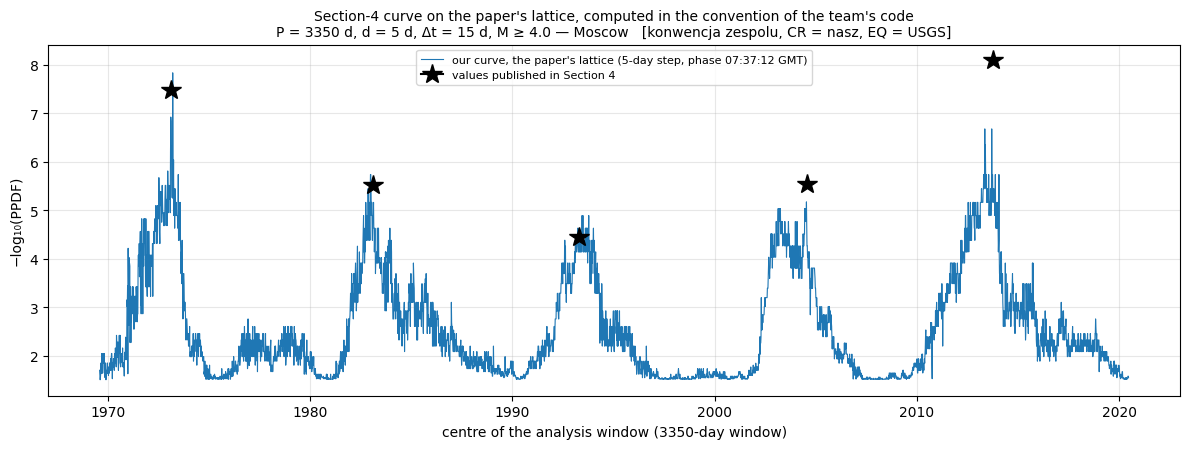

In [10]:
# RYSUNEK 2 - krzywa sekcji 4 w wybranej konfiguracji, z opublikowanymi punktami.
# Jedno kodowanie: wysokosc = sila efektu, os pozioma = czas.
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(krzywa["srodek_okna"], krzywa["neglog10_PPDF"], lw=0.8, color="tab:blue",
        label=OP["leg_krzywa"])
for _, r in ARTYKUL.iterrows():
    _t = MIN1_NA_KRACIE if r["nr"] == 1 else r["t0"]
    ax.plot(_t + pd.Timedelta(days=P_DAYS / 2), r["neglog10_PPDF"], marker="*", ms=15,
            color="black", zorder=5,
            label=OP["leg_punkty"] if r["nr"] == 1 else None)
ax.set_xlabel(OP["os_x_srodek"])
ax.set_ylabel(OP["os_y_krzywa"])
ax.set_title(OP["tytul2"] + f"   [{NAJLEPSZA['konwencja']}, CR = {NAJL_CR}, EQ = {NAJL_EQ}]",
             fontsize=10)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/replikacja_glebokosc_krzywa_{JEZYK}.png", dpi=150)
plt.show()

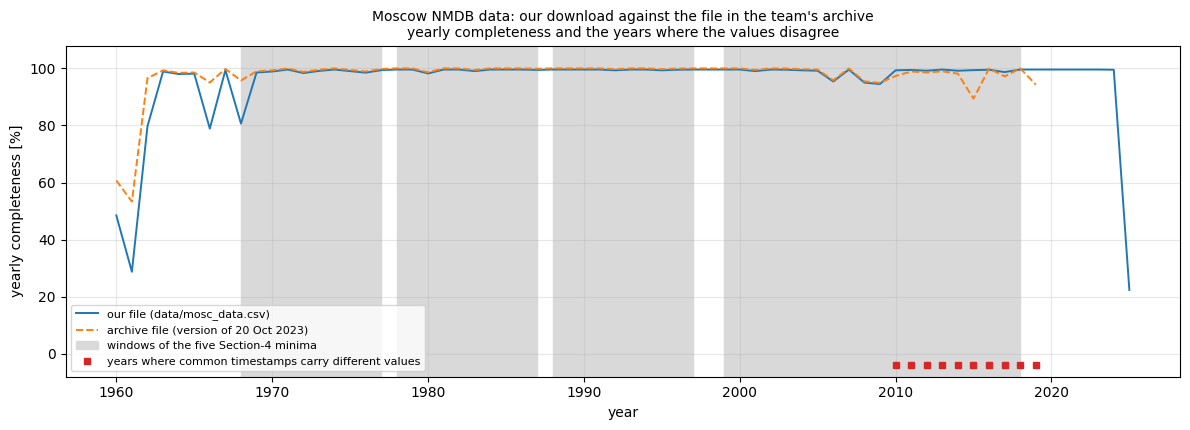

In [11]:
# RYSUNEK 3 - dane CR Moskwy: nasze pobranie wobec archiwum. Jedno kodowanie:
# wysokosc = kompletnosc roczna. Lata, w ktorych wartosci na wspolnych
# znacznikach sie roznia, sa zaznaczone osobnym pasem u dolu, a nie kolorem
# krzywej - zeby nie mieszac dwoch komunikatow w jednym kanale.
def kompletnosc_roczna(seria):
    zliczenia = seria.groupby(seria.index.year).size()
    lata = pd.Series(zliczenia.index, index=zliczenia.index)
    oczekiwane = lata.map(lambda r: (366 if pd.Timestamp(f"{r}-12-31").dayofyear == 366 else 365) * 4)
    return 100 * zliczenia / oczekiwane


kn = kompletnosc_roczna(mosc_nasz)
ka = kompletnosc_roczna(mosc_arch)
_wsp = mosc_nasz.index.intersection(mosc_arch.index)
_r = (np.abs(mosc_nasz.loc[_wsp] - mosc_arch.loc[_wsp]) > 1e-9)
lata_rozne = sorted({t.year for t in _wsp[_r]})

fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(kn.index, kn.values, lw=1.4, color="tab:blue", label=OP["leg_nasz"])
ax.plot(ka.index, ka.values, lw=1.4, color="tab:orange", ls="--", label=OP["leg_arch"])
for i, (_, r) in enumerate(ARTYKUL.iterrows()):
    _t = MIN1_NA_KRACIE if r["nr"] == 1 else r["t0"]
    ax.axvspan(_t.year, (_t + pd.Timedelta(days=P_DAYS)).year, color="0.85", zorder=0,
               label=OP["leg_okna"] if i == 0 else None)
if lata_rozne:
    ax.plot(lata_rozne, [-4] * len(lata_rozne), marker="s", ms=4, ls="none",
            color="tab:red", clip_on=False, label=OP["leg_rozne"])
ax.set_xlabel(OP["os_x_rok"])
ax.set_ylabel(OP["os_y_kompletnosc"])
ax.set_ylim(-8, 108)
ax.set_title(OP["tytul3"], fontsize=10)
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/replikacja_glebokosc_dane_cr_{JEZYK}.png", dpi=150)
plt.show()

In [ ]:
# KOMORKA 12 - PODSUMOWANIE DO DZIENNIKA. Nic nie liczy, zbiera w jednym miejscu
# liczby, ktore maja trafic do 20260905.txt.
print("=" * 84)
print("GLEBOKOSC MINIMOW SEKCJI 4, MOSKWA - PODSUMOWANIE")
print("=" * 84)

print("\n1. WALIDACJA PIPELINE'U")
print(f"   credo_stat[NASZE] == cosmoseismic_stat na 8 punktach, Np i Nm co do bitu.")
print(f"   credo_stat[CREDO] + dane zespolu == zapisana tabela zespolu, 332 kosze,")
print(f"   wszystkie kolumny, PPDF zgodne do 15 cyfr (3,509338616358831e-08).")

print("\n2. CO ROBI KONWENCJA ZESPOLU, CZEGO NIE ROBILA NASZA")
_z = credo_kosze(mosc_arch, eq_arch, T0_SEKCJA3, P3_DAYS, D_DAYS, DT_DAYS, **CREDO)
print(f"   kotwica kraty CR nie jest t0, tylko pierwsza probka po t0 - d;")
print(f"   kotwica kraty EQ to czas PIERWSZEGO TRZESIENIA po t0 + dt - d;")
print(f"   dla punktu sekcji 3 daje to jitter CR {_z['jitter_cr_h']:+.3f} h, "
      f"EQ {_z['jitter_eq_h']:+.4f} h,")
print(f"   czyli efektywne dt = {_z['dt_efektywne_d']:.6f} dnia zamiast {DT_DAYS}.")
print(f"   Do tego okno zaczyna sie o jeden kosz wczesniej (335 par zamiast 334")
print(f"   przy P = 1675; 670 zamiast 669 przy P = 3350).")

print("\n3. SEKCJA 3, MOSKWA - DRABINA (cel artykulu: 218/113, dystans 0)")
for _, r in drabina[drabina["blok"] == "kumulatywnie"].iterrows():
    print(f"   {r['wariant']:<40} Np = {int(r['Np']):>3}, Nm = {int(r['Nm']):>3}, "
          f"dystans = {int(r['dystans']):>2}")
_d3 = drabina[(drabina["blok"] == "dane") & (drabina["wariant"] == "konwencja zespolu")]
for _, r in _d3.iterrows():
    print(f"   konwencja zespolu, CR {r['CR']:<12} EQ {r['EQ']:<9} Np = {int(r['Np']):>3}, "
          f"Nm = {int(r['Nm']):>3}, dystans = {int(r['dystans']):>2}")

print("\n4. SEKCJA 4 - NADWYZKA ZNAKOW W OPUBLIKOWANYCH PUNKTACH")
print("   (cel = |Np - N/2| odczytane z opublikowanego PPDF, komorka 1;")
print("    PPDF nie niesie znaku, wiec porownujemy wartosci bezwzgledne)")
for nr, etykieta in ERY:
    cel = CEL[nr]
    print(f"   {etykieta:<28} cel {cel['nadwyzka']:+6.1f}", end="")
    for konw, crk in [("nasza konwencja", "nasz"), ("konwencja zespolu", "nasz"),
                      ("konwencja zespolu", "archiwum")]:
        w = punkty[(punkty["punkt"] == etykieta) & (punkty["konwencja"] == konw) &
                   (punkty["CR"] == crk) & (punkty["EQ"] == "USGS")]
        _v = f"{w['nadwyzka'].iloc[0]:+6.1f}" if not w.empty else "   n/d"
        print(f" | {konw[:8]}/{crk[:4]} {_v}", end="")
    print()

print("\n4b. ZNAK W POSZCZEGOLNYCH ERACH (osobny wynik, nie z artykulu)")
_zn = (punkty[(punkty["konwencja"] == "konwencja zespolu") & (punkty["CR"] == "archiwum") &
              (punkty["EQ"] == "USGS")][["punkt", "znak", "nadwyzka", "nadwyzka_cel"]])
print(_zn.to_string(index=False, float_format=lambda x: f"{x:8.1f}"))
print("   Cztery starsze ery wychodza DISORDERING, era 5 ORDERING. Era 5 jest")
_ile_ord = int((_zn["znak"] == "ordering").sum())
print(f"   jedyna era wewnatrz burning sample artykulu; er ordering: {_ile_ord} z {len(_zn)}.")
print("   To niezaleznie potwierdza decyzje z 31.08 o odwolaniu filtra")
print("   'tylko ordering' - ten filtr wyrzucalby cztery z pieciu er artykulu.")

print("\n4c. CZY FAZA Z BURNING SAMPLE PSUJE STARSZE ERY (komorka 7)")
print(podsum_faza.to_string(index=False, float_format=lambda x: f"{x:9.2f}"))

print("\n5. WYBRANA KONFIGURACJA I CO Z NIEJ WYNIKA")
print(f"   {NAJLEPSZA['konwencja']}, CR = {NAJL_CR}, EQ = {NAJL_EQ}")
print(f"   suma |braku nadwyzki| na erach 1-4: {NAJLEPSZA['suma_braku_nadwyzki']:.1f} znakow")
_e5 = podsum[(podsum["grupa"] == "era 5") & (podsum["konwencja"] == NAJLEPSZA["konwencja"]) &
             (podsum["CR"] == NAJL_CR) & (podsum["EQ"] == NAJL_EQ)]
if not _e5.empty:
    print(f"   era 5 osobno: {_e5['suma_braku_nadwyzki'].iloc[0]:.1f} znakow, "
          f"{_e5['suma_braku_dekad'].iloc[0]:.2f} dekady")
print("   istotnosc po karze, punkty sztywne:")
for _, r in istotnosc.iterrows():
    print(f"     {r['wariant']:<38} p = {r['p']:.3e}, sigma = {r['sigma']:.2f}")

print("\n6. CZEGO TO NIE ROZSTRZYGA")
print("   - znaku poszczegolnych er NIE da sie sprawdzic wobec artykulu, bo sekcja 4")
print("     podaje tylko PPDF, ktore jest symetryczne wzgledem Np <-> Nm. Nasz podzial")
print("     4 disordering + 1 ordering jest wiec obserwacja, a nie odtworzeniem.")
print("   - opublikowanych 218/113 dla sekcji 3 nie osiaga zadna kombinacja konwencji")
print("     i plikow, ktore mamy; najblizej jest 214/118 (konwencja + dane zespolu),")
print("     dokladnie tak jak 19.08. Ta reszta zostaje otwarta.")
print("   - roznica naszego pliku CR wobec archiwum po 2010-01-01 nie zostala")
print("     wyjasniona co do zrodla; do sprawdzenia sa inne warianty produktu NMDB")
print("     (nasz skrypt bierze tabchoice=revori&dtype=corr_for_efficiency).")
print("   - 62-dniowa dziura w naszym pliku CR w 1968 (1968-06-30 -> 1968-09-01)")
print("     obejmuje t0 pierwszego minimum artykulu; archiwum ma tam dziure 8-dniowa.")
print("     Wynik ery 1 na naszym pliku jest przez to nieporownywalny z artykulem.")

print("\nPLIKI:")
for _p in ["replikacja_glebokosc_pokrycie.csv", "replikacja_glebokosc_drabina_sekcja3.csv",
           "replikacja_glebokosc_piec_punktow.csv", "replikacja_glebokosc_faza_binu.csv",
           "replikacja_glebokosc_krzywa_credo_mosc.csv",
           "replikacja_glebokosc_istotnosc.csv",
           f"replikacja_glebokosc_np_{JEZYK}.png", f"replikacja_glebokosc_krzywa_{JEZYK}.png",
           f"replikacja_glebokosc_dane_cr_{JEZYK}.png"]:
    print(f"   {RESULTS_DIR}/{_p}")